In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cic-10gb/01-12/DrDoS_NetBIOS.csv
/kaggle/input/cic-10gb/01-12/DrDoS_NTP.csv
/kaggle/input/cic-10gb/01-12/UDPLag.csv
/kaggle/input/cic-10gb/01-12/Syn.csv
/kaggle/input/cic-10gb/01-12/DrDoS_MSSQL.csv
/kaggle/input/cic-10gb/01-12/DrDoS_SNMP.csv
/kaggle/input/cic-10gb/01-12/DrDoS_DNS.csv
/kaggle/input/cic-10gb/01-12/DrDoS_LDAP.csv


In [13]:
!pip install pyspark


In [14]:
from pyspark.sql import SparkSession

# Khởi tạo SparkSession
spark = SparkSession.builder \
    .appName("Combine_CSV_to_Parquet") \
    .getOrCreate()

# Đọc tất cả file CSV trong thư mục /01-12/ vào DataFrame
csv_path = "/kaggle/input/cic-10gb/01-12/*.csv"
df_all = spark.read.csv(csv_path, header=True, inferSchema=True)

# Kiểm tra schema của DataFrame
df_all.printSchema()


root
 |-- Unnamed: 0: integer (nullable = true)
 |-- Flow ID: string (nullable = true)
 |--  Source IP: string (nullable = true)
 |--  Source Port: integer (nullable = true)
 |--  Destination IP: string (nullable = true)
 |--  Destination Port: integer (nullable = true)
 |--  Protocol: integer (nullable = true)
 |--  Timestamp: timestamp (nullable = true)
 |--  Flow Duration: integer (nullable = true)
 |--  Total Fwd Packets: integer (nullable = true)
 |--  Total Backward Packets: integer (nullable = true)
 |-- Total Length of Fwd Packets: double (nullable = true)
 |--  Total Length of Bwd Packets: double (nullable = true)
 |--  Fwd Packet Length Max: double (nullable = true)
 |--  Fwd Packet Length Min: double (nullable = true)
 |--  Fwd Packet Length Mean: double (nullable = true)
 |--  Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: double (nullable = true)
 |--  Bwd Packet Length Min: double (nullable = true)
 |--  Bwd Packet Length Mean: double (nullabl

In [15]:
df_all.write.mode("overwrite").parquet("/kaggle/working/cic10gb_full.parquet")


In [16]:
df_parquet = spark.read.parquet("/kaggle/working/cic10gb_full.parquet")
# Loại bỏ khoảng trắng trong tên cột
df_parquet = df_parquet.toDF(*[col.strip() for col in df_parquet.columns])

# Kiểm tra lại tên cột
print(df_parquet.columns)


['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag

In [17]:
# Kiểm tra loại dữ liệu của tất cả các cột
df_parquet.dtypes


[('Unnamed: 0', 'int'),
 ('Flow ID', 'string'),
 ('Source IP', 'string'),
 ('Source Port', 'int'),
 ('Destination IP', 'string'),
 ('Destination Port', 'int'),
 ('Protocol', 'int'),
 ('Timestamp', 'timestamp'),
 ('Flow Duration', 'int'),
 ('Total Fwd Packets', 'int'),
 ('Total Backward Packets', 'int'),
 ('Total Length of Fwd Packets', 'double'),
 ('Total Length of Bwd Packets', 'double'),
 ('Fwd Packet Length Max', 'double'),
 ('Fwd Packet Length Min', 'double'),
 ('Fwd Packet Length Mean', 'double'),
 ('Fwd Packet Length Std', 'double'),
 ('Bwd Packet Length Max', 'double'),
 ('Bwd Packet Length Min', 'double'),
 ('Bwd Packet Length Mean', 'double'),
 ('Bwd Packet Length Std', 'double'),
 ('Flow Bytes/s', 'double'),
 ('Flow Packets/s', 'double'),
 ('Flow IAT Mean', 'double'),
 ('Flow IAT Std', 'double'),
 ('Flow IAT Max', 'double'),
 ('Flow IAT Min', 'double'),
 ('Fwd IAT Total', 'double'),
 ('Fwd IAT Mean', 'double'),
 ('Fwd IAT Std', 'double'),
 ('Fwd IAT Max', 'double'),
 ('Fwd IA

In [18]:
from pyspark.sql.functions import col, when

# Danh sách cột cần xử lý
bigint_cols = ['Fwd Header Length', 'Fwd Header Length.1']

# Cách 1: Dùng backtick để escape tên cột có khoảng trắng (KHUYẾN CÁO)
for col_name in bigint_cols:
    df_parquet = df_parquet.withColumn(
        col_name,
        col(f"`{col_name}`").cast("long")   # Dùng backtick
    )

# Điền giá trị null bằng 0
for col_name in bigint_cols:
    df_parquet = df_parquet.withColumn(
        col_name,
        when(col(f"`{col_name}`").isNull(), 0).otherwise(col(f"`{col_name}`"))
    )

In [19]:

problem_cols = ["Fwd Header Length", "Fwd Header Length.1"]

# Drop 2 thằng quỷ này luôn và ngay lập tức
df_parquet = df_parquet.drop(*problem_cols)

print("drop")

drop


In [20]:

numeric_cols = [c for c, t in df_parquet.dtypes if t in ("int","bigint","long","float","double")]
string_cols   = [c for c, t in df_parquet.dtypes if t == "string"]
timestamp_cols = [c for c, t in df_parquet.dtypes if t == "timestamp"]

# Fillna cho tất cả numeric
df_parquet = df_parquet.fillna(0, subset=numeric_cols) \
                       .fillna("unknown", subset=string_cols) \
                       .fillna("1970-01-01 00:00:00", subset=timestamp_cols)

# ép kiểu đồng bộ 
for c in numeric_cols:
    if dict(df_parquet.dtypes)[c] == "bigint":
        df_parquet = df_parquet.withColumn(c, col(f"`{c}`").cast("long"))

In [21]:
train_df, val_df, test_df = df_parquet.randomSplit([0.7, 0.15, 0.15], seed=42)


In [22]:
train_df.write.mode("overwrite").parquet("/kaggle/working/train.parquet")
val_df.write.mode("overwrite").parquet("/kaggle/working/val.parquet")
test_df.write.mode("overwrite").parquet("/kaggle/working/test.parquet")


In [23]:

problematic_cols = [c for c in train_df.columns if "Header Length" in c or "Fwd Header Length" in c]

print("drop các cột gây lỗi:", problematic_cols)

train_df = train_df.drop(*problematic_cols)
val_df   = val_df.drop(*problematic_cols)
test_df  = test_df.drop(*problematic_cols)

# BƯỚC 2: Lọc lại numeric features (đã sạch hoàn toàn)
label_col = "Label"  # đổi nếu tên khác

numeric_features = [
    c for c, t in train_df.dtypes 
    if t in ("int", "bigint", "long", "double", "float") and c != label_col
]

print(f"Số feature numeric sau khi làm sạch: {len(numeric_features)}")

drop các cột gây lỗi: ['Bwd Header Length']
Số feature numeric sau khi làm sạch: 79


In [24]:
# CELL 1: Import và chuẩn bị Spark (chạy 1 lần)
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, IndexToString
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pyspark.sql.functions as F

spark = SparkSession.builder \
    .appName("RandomForest_Intrusion_Detection") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

25/12/21 09:22:26 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [25]:
# CELL 2: Đọc lại dữ liệu đã lưu trước đó
train_df = spark.read.parquet("/kaggle/working/train.parquet")
val_df   = spark.read.parquet("/kaggle/working/val.parquet")
test_df  = spark.read.parquet("/kaggle/working/test.parquet")

print(f"Train: {train_df.count():,} rows")
print(f"Val:   {val_df.count():,} rows")
print(f"Test:  {test_df.count():,} rows")

Train: 16,947,194 rows
Val:   3,628,077 rows
Test:  3,631,838 rows


In [26]:
cols_to_drop = [
    "Fwd Header Length", "Fwd Header Length.1", 
    "Flow ID", "Src IP", "Source IP", "Dst IP", "Destination IP",
    "Timestamp", "SimillarHTTP", "Unnamed: 0", "Unnamed: 0.1", "index"
]

train_df = train_df.drop(*[c for c in cols_to_drop if c in train_df.columns])
val_df   = val_df.drop(*[c for c in cols_to_drop if c in val_df.columns])
test_df  = test_df.drop(*[c for c in cols_to_drop if c in test_df.columns])

print("Đã drop sạch 100% cột lỗi!")


Đã drop sạch 100% cột lỗi!


In [ ]:


from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType, LongType, IntegerType

# Danh sách các cột là số (thường có trong mọi bộ IDS)
expected_numeric_cols = [
    "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets",
    "Fwd Packet Length Max", "Fwd Packet Length Min", "Fwd Packet Length Mean", "Fwd Packet Length Std",
    "Bwd Packet Length Max", "Bwd Packet Length Min", "Bwd Packet Length Mean", "Bwd Packet Length Std",
    "Flow Bytes/s", "Flow Packets/s", "Flow IAT Mean", "Flow IAT Std", "Flow IAT Max", "Flow IAT Min",
    "Fwd IAT Total", "Fwd IAT Mean", "Fwd IAT Std", "Fwd IAT Max", "Fwd IAT Min",
    "Bwd IAT Total", "Bwd IAT Mean", "Bwd IAT Std", "Bwd IAT Max", "Bwd IAT Min",
    "Fwd PSH Flags", "Bwd PSH Flags", "Fwd URG Flags", "Bwd URG Flags",
    "Fwd Header Length", "Bwd Header Length", "Fwd Packets/s", "Bwd Packets/s",
    "Min Packet Length", "Max Packet Length", "Packet Length Mean", "Packet Length Std", "Packet Length Variance",
    "FIN Flag Count", "SYN Flag Count", "RST Flag Count", "PSH Flag Count", "ACK Flag Count", "URG Flag Count", "CWE Flag Count", "ECE Flag Count",
    "Down/Up Ratio", "Average Packet Size", "Avg Fwd Segment Size", "Avg Bwd Segment Size",
    "Subflow Fwd Packets", "Subflow Fwd Bytes", "Subflow Bwd Packets", "Subflow Bwd Bytes",
    "Init_Win_bytes_forward", "Init_Win_bytes_backward", "act_data_pkt_fwd", "min_seg_size_forward",
    "Active Mean", "Active Std", "Active Max", "Active Min",
    "Idle Mean", "Idle Std", "Idle Max", "Idle Min",
    "Source Port", "Destination Port", "Protocol",
    # Thêm bất kỳ cột số nào bạn thấy trong dữ liệu
]

# Lọc chỉ những cột thực sự tồn tại trong DataFrame
existing_numeric_cols = [c for c in expected_numeric_cols if c in train_df.columns]

print(f"Tìm thấy {len(existing_numeric_cols)} cột numeric để ép kiểu...")

# Ép kiểu: ưu tiên Long → Double nếu có giá trị lớn/inf
for c in existing_numeric_cols:
    # Thử ép Long trước
    train_df = train_df.withColumn(c, col(c).cast(LongType()))
    val_df   = val_df.withColumn(c, col(c).cast(LongType()))
    test_df  = test_df.withColumn(c, col(c).cast(LongType()))
    try:
        train_df.head(1)
    except:
        print(f"  → {c} quá lớn cho Long → chuyển sang Double")
        train_df = train_df.withColumn(c, col(c).cast(DoubleType()))
        val_df   = val_df.withColumn(c, col(c).cast(DoubleType()))
        test_df  = test_df.withColumn(c, col(c).cast(DoubleType()))

for df in [train_df, val_df, test_df]:
    df = df.replace(float('inf'), 0).replace(float('-inf'), 0).fillna(0, subset=existing_numeric_cols)

print("ÉP KIỂU THÀNH CÔNG!")

Tìm thấy 72 cột numeric để ép kiểu...


In [28]:

label_col = "Label"  # hoặc tên thực tế

numeric_features = [
    c for c, t in train_df.dtypes 
    if t in ("int", "bigint", "long", "double", "float") and c != label_col
]

print(f"Số feature numeric sẽ dùng: {len(numeric_features)}")
print("Ví dụ top 10:", numeric_features[:10])

Số feature numeric sẽ dùng: 79
Ví dụ top 10: ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min']


In [29]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("RF_Final") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.sql.shuffle.partitions", "100") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

print("Spark khởi động đúng cách – SẴN SÀNG TRAIN!")


Spark khởi động đúng cách – SẴN SÀNG TRAIN!


25/12/21 09:22:54 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [30]:

train_df = spark.read.parquet("/kaggle/working/train.parquet")
val_df   = spark.read.parquet("/kaggle/working/val.parquet")
test_df  = spark.read.parquet("/kaggle/working/test.parquet")


drop_cols = ["Fwd Header Length", "Fwd Header Length.1", "Flow ID", "Src IP", "Source IP",
             "Dst IP", "Destination IP", "Timestamp", "SimillarHTTP", "Unnamed: 0", "index"]
for df in [train_df, val_df, test_df]:
    df = df.drop(*[c for c in drop_cols if c in df.columns])

from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType

# Tất cả cột không phải Label → ép Double
for c in train_df.columns:
    if c != "Label":
        train_df = train_df.withColumn(c, col(c).cast(DoubleType())).fillna(0, subset=[c])
        val_df   = val_df.withColumn(c, col(c).cast(DoubleType())).fillna(0, subset=[c])
        test_df  = test_df.withColumn(c, col(c).cast(DoubleType())).fillna(0, subset=[c])

train_df = train_df.fillna("Benign", subset=["Label"])
val_df   = val_df.fillna("Benign", subset=["Label"])

print("DỮ LIỆU ĐÃ SẠCH HOÀN TOÀN – TRAIN!")

DỮ LIỆU ĐÃ SẠCH HOÀN TOÀN – TRAIN!


In [31]:
from pyspark.sql.functions import when

# Kiểm tra NaN và Infinity
for col_name in train_df.columns:
    train_df = train_df.withColumn(col_name, when((train_df[col_name].isNull()) | 
                                                  (train_df[col_name] == float('inf')) |
                                                  (train_df[col_name] == float('-inf')), 0).otherwise(train_df[col_name]))



In [32]:
# CELL 3 – TRAIN SIÊU NHẸ (100 cây, 60% data )
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, IndexToString
from pyspark.ml.classification import RandomForestClassifier

label_col = "Label"
feature_cols = [c for c in train_df.columns if c != label_col]

indexer = StringIndexer(inputCol=label_col, outputCol="label_idx", handleInvalid="keep")
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

rf = RandomForestClassifier(
    labelCol="label_idx", featuresCol="features",
    numTrees=50,  # Giảm số cây
    maxDepth=8,   # Giảm độ sâu của cây
    maxBins=32,
    subsamplingRate=0.6,
    seed=42
)


converter = IndexToString(inputCol="prediction", outputCol="predicted_label",
                          labels=indexer.fit(train_df).labels)

pipeline = Pipeline(stages=[indexer, assembler, rf, converter])

# Dùng 60% train để chắc chắn không OOM
train_light = train_df.sample(False, 0.6, seed=42)

print("Bắt đầu train")
rf_model = pipeline.fit(train_light)
print("DONE")

Bắt đầu train


25/12/21 09:41:28 WARN MemoryStore: Not enough space to cache rdd_404_1 in memory! (computed 100.3 MiB so far)
25/12/21 09:41:28 WARN BlockManager: Persisting block rdd_404_1 to disk instead.
25/12/21 09:41:29 WARN MemoryStore: Not enough space to cache rdd_404_3 in memory! (computed 100.3 MiB so far)
25/12/21 09:41:29 WARN BlockManager: Persisting block rdd_404_3 to disk instead.
25/12/21 09:41:50 WARN MemoryStore: Not enough space to cache rdd_404_2 in memory! (computed 151.4 MiB so far)
25/12/21 09:41:50 WARN BlockManager: Persisting block rdd_404_2 to disk instead.
25/12/21 09:42:58 WARN MemoryStore: Not enough space to cache rdd_404_0 in memory! (computed 356.0 MiB so far)
25/12/21 09:42:58 WARN BlockManager: Persisting block rdd_404_0 to disk instead.
25/12/21 09:43:21 WARN MemoryStore: Not enough space to cache rdd_404_0 in memory! (computed 356.0 MiB so far)
25/12/21 09:44:46 WARN MemoryStore: Not enough space to cache rdd_404_2 in memory! (computed 100.3 MiB so far)
25/12/21 0

DONE


In [33]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Dự đoán kết quả cho tập validation và test
val_predictions = rf_model.transform(val_df)
test_predictions = rf_model.transform(test_df)

# Khởi tạo evaluator để tính toán các chỉ số đánh giá
evaluator = MulticlassClassificationEvaluator(
    labelCol="label_idx", predictionCol="prediction", metricName="f1"
)

# Tính F1-Score cho tập validation và test
val_f1 = evaluator.evaluate(val_predictions)
test_f1 = evaluator.evaluate(test_predictions)

# Tính Accuracy cho tập validation và test
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_idx", predictionCol="prediction", metricName="accuracy"
)

val_accuracy = accuracy_evaluator.evaluate(val_predictions)
test_accuracy = accuracy_evaluator.evaluate(test_predictions)

# Tính Precision và Recall
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision"
)
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall"
)

val_precision = precision_evaluator.evaluate(val_predictions)
test_precision = precision_evaluator.evaluate(test_predictions)

val_recall = recall_evaluator.evaluate(val_predictions)
test_recall = recall_evaluator.evaluate(test_predictions)

# In kết quả
print("Validation Results:")
print(f"F1-Score: {val_f1:.4f}")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")

print("\nTest Results:")
print(f"F1-Score: {test_f1:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")

# Optional: In confusion matrix
from pyspark.mllib.evaluation import MulticlassMetrics
pred_and_labels = val_predictions.select("prediction", "label_idx").rdd
metrics = MulticlassMetrics(pred_and_labels)
confusion_matrix = metrics.confusionMatrix()
print("Confusion Matrix:")
print(confusion_matrix)


25/12/21 10:02:33 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
25/12/21 10:05:31 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
25/12/21 10:08:25 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
25/12/21 10:11:18 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
25/12/21 10:14:09 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
25/12/21 10:17:01 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
25/12/21 10:19:44 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
25/12/21 10:22:33 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


Validation Results:
F1-Score: 0.9591
Accuracy: 0.9618
Precision: 0.9636
Recall: 0.9618

Test Results:
F1-Score: 0.9593
Accuracy: 0.9619
Precision: 0.9637
Recall: 0.9619


/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
25/12/21 10:25:27 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/12/21 10:25:29 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


Confusion Matrix:
DenseMatrix([[7.37026e+05, 6.11000e+02, 5.54000e+02, 3.48950e+04, 3.89000e+02,
              3.00000e+01, 3.00000e+01, 2.10000e+01, 1.12000e+02, 0.00000e+00],
             [3.46000e+02, 7.35008e+05, 2.97000e+02, 6.80000e+01, 2.22520e+04,
              5.00000e+00, 1.86800e+03, 6.00000e+00, 1.14000e+02, 0.00000e+00],
             [1.03000e+02, 2.25000e+02, 6.73467e+05, 0.00000e+00, 4.22100e+03,
              1.00000e+00, 1.40000e+01, 1.00000e+01, 6.00000e+01, 0.00000e+00],
             [3.00000e+00, 5.60000e+01, 7.32100e+03, 6.04503e+05, 1.70000e+01,
              9.50000e+01, 7.00000e+00, 8.00000e+00, 6.10000e+01, 0.00000e+00],
             [3.94600e+03, 1.86280e+04, 2.84000e+02, 0.00000e+00, 3.04414e+05,
              1.00000e+01, 9.00000e+00, 0.00000e+00, 4.50000e+01, 0.00000e+00],
             [1.10000e+01, 4.00000e+00, 7.00000e+00, 3.20000e+01, 0.00000e+00,
              2.36806e+05, 4.00000e+00, 7.80000e+01, 8.00000e+00, 0.00000e+00],
             [0.00000e+00, 1

/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
25/12/21 10:28:22 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/12/21 10:28:23 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


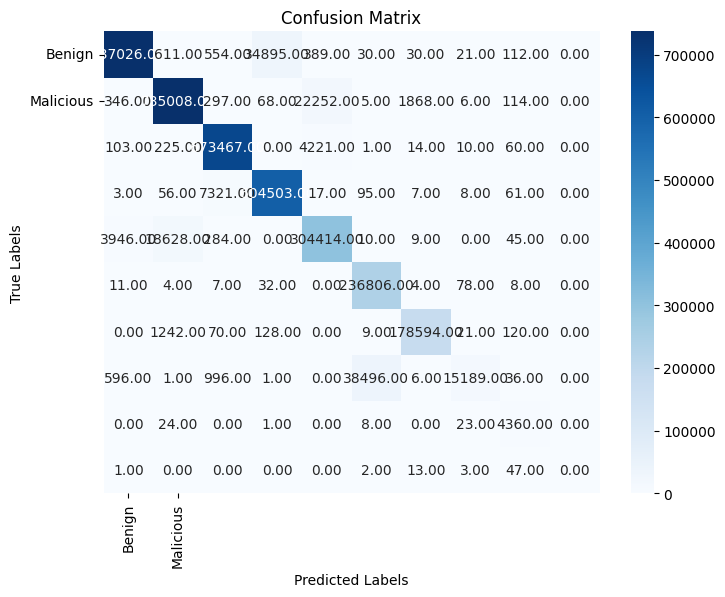

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.mllib.evaluation import MulticlassMetrics

# Dự đoán trên tập validation
pred_and_labels = val_predictions.select("prediction", "label_idx").rdd

# Tạo confusion matrix
metrics = MulticlassMetrics(pred_and_labels)
confusion_matrix = metrics.confusionMatrix().toArray()

# Visualize confusion matrix bằng heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=["Benign", "Malicious"], yticklabels=["Benign", "Malicious"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()



In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, isnan
from pyspark.sql.types import LongType, DoubleType, NumericType

# Khởi tạo SparkSession
spark = SparkSession.builder \
    .appName("Data_Preprocessing") \
    .getOrCreate()

# Đọc tất cả file CSV trong thư mục /01-12/ vào DataFrame
csv_path = "/kaggle/input/cic-10gb/01-12/*.csv"
df_all = spark.read.csv(csv_path, header=True, inferSchema=True)

# Kiểm tra schema của DataFrame
df_all.printSchema()

# Lưu dữ liệu thành định dạng Parquet
df_all.write.mode("overwrite").parquet("/kaggle/working/cic10gb_full.parquet")
df_parquet = spark.read.parquet("/kaggle/working/cic10gb_full.parquet")

# Loại bỏ khoảng trắng trong tên cột
df_parquet = df_parquet.toDF(*[col.strip() for col in df_parquet.columns])

# Kiểm tra lại tên cột
print(df_parquet.columns)

# Danh sách cột cần xử lý (ví dụ cột có khoảng trắng hoặc lỗi)
bigint_cols = ['Fwd Header Length', 'Fwd Header Length.1']

# Xử lý các cột có tên chứa khoảng trắng và chuyển đổi kiểu dữ liệu
for col_name in bigint_cols:
    df_parquet = df_parquet.withColumn(
        col_name,
        col(f"`{col_name}`").cast("long")   # Dùng backtick để tránh lỗi tên cột chứa khoảng trắng
    )

# Điền giá trị null bằng 0 cho các cột này
for col_name in bigint_cols:
    df_parquet = df_parquet.withColumn(
        col_name,
        when(col(f"`{col_name}`").isNull(), 0).otherwise(col(f"`{col_name}`"))
    )

# Loại bỏ các cột không cần thiết
problem_cols = ["Fwd Header Length", "Fwd Header Length.1"]
df_parquet = df_parquet.drop(*problem_cols)

print("Đã xóa các cột gây lỗi! Bây giờ có thể tiếp tục xử lý!")

# Xử lý dữ liệu thiếu (null, NaN, Infinity) cho các cột số học
numeric_cols = [c for c, t in df_parquet.dtypes if t in ("int", "bigint", "long", "float", "double")]
string_cols = [c for c, t in df_parquet.dtypes if t == "string"]
timestamp_cols = [c for c, t in df_parquet.dtypes if t == "timestamp"]

# Điền giá trị thiếu cho các cột số học, chuỗi và timestamp
df_parquet = df_parquet.fillna(0, subset=numeric_cols) \
                       .fillna("unknown", subset=string_cols) \
                       .fillna("1970-01-01 00:00:00", subset=timestamp_cols)

# Nếu cần ép kiểu đồng bộ cho các cột numeric (ví dụ: bigint → long)
for c in numeric_cols:
    if dict(df_parquet.dtypes)[c] == "bigint":
        df_parquet = df_parquet.withColumn(c, col(f"`{c}`").cast("long"))

# Chia dữ liệu thành các bộ train, validation, test
train_df, val_df, test_df = df_parquet.randomSplit([0.7, 0.15, 0.15], seed=42)

# Lưu dữ liệu đã chia thành định dạng Parquet
train_df.write.mode("overwrite").parquet("/kaggle/working/train.parquet")
val_df.write.mode("overwrite").parquet("/kaggle/working/val.parquet")
test_df.write.mode("overwrite").parquet("/kaggle/working/test.parquet")

# Kiểm tra số lượng dòng sau khi chia
print(f"Train: {train_df.count():,} rows")
print(f"Val:   {val_df.count():,} rows")
print(f"Test:  {test_df.count():,} rows")

# Xử lý loại bỏ các cột không cần thiết trước khi huấn luyện
cols_to_drop = ["Fwd Header Length", "Fwd Header Length.1", "Flow ID", "Src IP", "Source IP", "Dst IP", "Destination IP",
                "Timestamp", "SimillarHTTP", "Unnamed: 0", "Unnamed: 0.1", "index"]
train_df = train_df.drop(*[c for c in cols_to_drop if c in train_df.columns])
val_df   = val_df.drop(*[c for c in cols_to_drop if c in val_df.columns])
test_df  = test_df.drop(*[c for c in cols_to_drop if c in test_df.columns])

print("Đã drop cột lỗi! Sẵn sàng cho quá trình huấn luyện!")

# Ép kiểu đồng bộ cho các cột số học
numeric_cols = [field.name for field in train_df.schema.fields if isinstance(field.dataType, NumericType)]

# Tạo danh sách các cột numeric thực sự tồn tại trong DataFrame
existing_numeric_cols = [c for c in numeric_cols if c in train_df.columns]

# Ép kiểu tất cả các cột số học thành DoubleType
for c in existing_numeric_cols:
    train_df = train_df.withColumn(c, col(c).cast(DoubleType()))
    val_df = val_df.withColumn(c, col(c).cast(DoubleType()))
    test_df = test_df.withColumn(c, col(c).cast(DoubleType()))

# Xử lý Infinity và NaN trên các cột số học
for df in [train_df, val_df, test_df]:
    df = df.replace(float('inf'), 0).replace(float('-inf'), 0).fillna(0, subset=existing_numeric_cols)

# Kiểm tra dữ liệu sau khi xử lý
train_df.show(5)
val_df.show(5)
test_df.show(5)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/21 10:33:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/21 10:37:42 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


root
 |-- Unnamed: 0: integer (nullable = true)
 |-- Flow ID: string (nullable = true)
 |--  Source IP: string (nullable = true)
 |--  Source Port: integer (nullable = true)
 |--  Destination IP: string (nullable = true)
 |--  Destination Port: integer (nullable = true)
 |--  Protocol: integer (nullable = true)
 |--  Timestamp: timestamp (nullable = true)
 |--  Flow Duration: integer (nullable = true)
 |--  Total Fwd Packets: integer (nullable = true)
 |--  Total Backward Packets: integer (nullable = true)
 |-- Total Length of Fwd Packets: double (nullable = true)
 |--  Total Length of Bwd Packets: double (nullable = true)
 |--  Fwd Packet Length Max: double (nullable = true)
 |--  Fwd Packet Length Min: double (nullable = true)
 |--  Fwd Packet Length Mean: double (nullable = true)
 |--  Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: double (nullable = true)
 |--  Bwd Packet Length Min: double (nullable = true)
 |--  Bwd Packet Length Mean: double (nullabl

['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag

Train: 16,947,194 rows


Val:   3,628,077 rows


Test:  3,631,838 rows
Đã drop cột lỗi! Sẵn sàng cho quá trình huấn luyện!


+-----------+----------------+--------+-------------+-----------------+----------------------+---------------------------+---------------------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+-------------------+------------------+------------------+------------------+------------+------------+-------------+------------------+------------------+-----------+-----------+-------------+-----------------+-----------------+-----------+-----------+-------------+-------------+-------------+-------------+-----------------+------------------+------------------+-----------------+-----------------+------------------+-----------------+----------------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+-------------------+--------------------+--------------------+---------------

+-----------+----------------+--------+-------------+-----------------+----------------------+---------------------------+---------------------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+------------------+------------------+-----------------+------------------+------------+------------+-------------+-----------------+-----------------+-----------+-----------+-------------+------------+-----------------+-----------+-----------+-------------+-------------+-------------+-------------+-----------------+------------------+-----------------+-----------------+-----------------+------------------+------------------+----------------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+-------------------+--------------------+--------------------+------------------+-----

+-----------+----------------+--------+-------------+-----------------+----------------------+---------------------------+---------------------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+--------------------+-----------------+------------------+------------------+------------+------------+-------------+------------------+------------------+-----------+-----------+-------------+------------+------------------+-----------+-----------+-------------+-------------+-------------+-------------+-----------------+------------------+-----------------+-----------------+-----------------+------------------+------------------+----------------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+-------------------+--------------------+--------------------+------------------+

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, isnan
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, PCA, StringIndexer, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd

# === 1. Khởi tạo Spark Session tối ưu cho Kaggle ===
spark.stop()  # đảm bảo không có session cũ
spark = SparkSession.builder \
    .appName("DDoS_Classification_With_PCA") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "12g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# === 2. Đọc dữ liệu Parquet đã tiền xử lý ===
train_df = spark.read.parquet("/kaggle/working/train.parquet")
val_df = spark.read.parquet("/kaggle/working/val.parquet")
test_df = spark.read.parquet("/kaggle/working/test.parquet")

# === 3. Lấy tất cả numeric columns làm feature ban đầu ===
all_numeric_cols = [c for c, t in train_df.dtypes if t in ('int', 'bigint', 'double', 'float')]
feature_cols_all = [c for c in all_numeric_cols if c != 'Label']

print(f"Tổng số numeric features ban đầu: {len(feature_cols_all)}")

# === 4. Hàm làm sạch NaN / Inf ===
def clean_df(df, cols):
    for c in cols:
        df = df.withColumn(c,
            when(col(c).isNull() | isnan(col(c)) |
                 (col(c) == float('inf')) | (col(c) == float('-inf')), 0.0)
            .otherwise(col(c))
        )
    return df

# === BƯỚC 1: Train RF nhẹ trên mẫu nhỏ để lấy feature importance ===
print("=== Bước 1: Lấy feature importance ===")
train_small = train_df.sample(False, 0.01, seed=42).cache()  # ~20-50k rows
train_small = clean_df(train_small, feature_cols_all)

assembler_temp = VectorAssembler(inputCols=feature_cols_all, outputCol="features_temp", handleInvalid="keep")
label_indexer = StringIndexer(inputCol="Label", outputCol="label", handleInvalid="keep")

rf_temp = RandomForestClassifier(labelCol="label", featuresCol="features_temp",
                                 numTrees=50, maxDepth=12, seed=42)

pipeline_temp = Pipeline(stages=[assembler_temp, label_indexer, rf_temp])
model_temp = pipeline_temp.fit(train_small)

# Lấy importance
rf_stage = model_temp.stages[-1]
importances = rf_stage.featureImportances.toArray()

importance_pd = pd.DataFrame({
    'feature': feature_cols_all,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 30 features quan trọng nhất:")
print(importance_pd.head(30))

# === BƯỚC 2: Chọn top features (ví dụ top 25) ===
top_k = 25
selected_features = importance_pd.head(top_k)['feature'].tolist()
print(f"\nĐã chọn {top_k} features quan trọng:")
print(selected_features)

# === BƯỚC 3: Chuẩn bị dữ liệu lớn hơn với features đã chọn + PCA ===
print("\n=== Bước 3: Train mô hình cuối với PCA trên features đã chọn ===")

# Sample lớn hơn một chút để mô hình tốt hơn (vẫn an toàn trên Kaggle)
train_final = train_df.sample(False, 0.05, seed=42).cache()   # ~5% train
val_final = val_df.sample(False, 0.1, seed=42)
test_final = test_df.sample(False, 0.1, seed=42)

# Làm sạch
train_final = clean_df(train_final, selected_features)
val_final = clean_df(val_final, selected_features)
test_final = clean_df(test_final, selected_features)

# Pipeline cuối cùng: Assemble → StandardScaler (rất quan trọng trước PCA) → PCA → RF
assembler = VectorAssembler(inputCols=selected_features, outputCol="features_assembled", handleInvalid="keep")

# StandardScaler giúp PCA hoạt động tốt hơn (mean=0, std=1)
scaler = StandardScaler(inputCol="features_assembled", outputCol="features_scaled", withStd=True, withMean=True)

pca = PCA(k=10, inputCol="features_scaled", outputCol="pca_features")  # k=8-12 thường đủ cho CIC-IDS

rf_final = RandomForestClassifier(
    labelCol="label",
    featuresCol="pca_features",
    numTrees=30,
    maxDepth=10,
    subsamplingRate=0.8,
    seed=42
)

pipeline_final = Pipeline(stages=[assembler, scaler, pca, label_indexer, rf_final])

# Huấn luyện
print("Đang huấn luyện mô hình cuối (có PCA)...")
model_final = pipeline_final.fit(train_final)

# Dự đoán
val_pred = model_final.transform(val_final)
test_pred = model_final.transform(test_final)

# Đánh giá
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

val_acc = evaluator_acc.evaluate(val_pred)
val_f1 = evaluator_f1.evaluate(val_pred)
test_acc = evaluator_acc.evaluate(test_pred)
test_f1 = evaluator_f1.evaluate(test_pred)

print("\n=== KẾT QUẢ MÔ HÌNH CUỐI (CÓ PCA) ===")
print(f"Validation Accuracy: {val_acc:.5f}")
print(f"Validation F1-Score: {val_f1:.5f}")
print(f"Test Accuracy     : {test_acc:.5f}")
print(f"Test F1-Score     : {test_f1:.5f}")

# Xem phân bố lớp để kiểm tra
print("\nPhân bố lớp trong train_final:")
train_final.groupBy("Label").count().orderBy(col("count").desc()).show()

# Xem vài dự đoán
print("\nMột số dự đoán trên test:")
test_pred.select("Label", "prediction", "probability").show(10, truncate=False)

Tổng số numeric features ban đầu: 80
=== Bước 1: Lấy feature importance ===


25/12/21 11:06:42 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB
25/12/21 11:06:45 WARN DAGScheduler: Broadcasting large task binary with size 1731.3 KiB
25/12/21 11:06:48 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
25/12/21 11:06:53 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/12/21 11:06:58 WARN DAGScheduler: Broadcasting large task binary with size 5.4 MiB
25/12/21 11:07:04 WARN DAGScheduler: Broadcasting large task binary with size 7.3 MiB
25/12/21 11:07:12 WARN DAGScheduler: Broadcasting large task binary with size 9.5 MiB
25/12/21 11:07:18 WARN DAGScheduler: Broadcasting large task binary with size 1027.7 KiB


Top 30 features quan trọng nhất:
                        feature  importance
40            Min Packet Length    0.109549
64            Subflow Fwd Bytes    0.103903
1                   Source Port    0.079930
55         Avg Fwd Segment Size    0.068255
7   Total Length of Fwd Packets    0.064867
54          Average Packet Size    0.058976
41            Max Packet Length    0.053984
42           Packet Length Mean    0.052220
10        Fwd Packet Length Min    0.047001
11       Fwd Packet Length Mean    0.043379
0                    Unnamed: 0    0.041361
9         Fwd Packet Length Max    0.030019
69             act_data_pkt_fwd    0.024308
17                 Flow Bytes/s    0.022557
4                 Flow Duration    0.017454
21                 Flow IAT Max    0.014832
67       Init_Win_bytes_forward    0.014829
22                 Flow IAT Min    0.014460
23                Fwd IAT Total    0.014281
27                  Fwd IAT Min    0.014086
5             Total Fwd Packets    0.012474

25/12/21 11:08:43 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB
25/12/21 11:08:48 WARN DAGScheduler: Broadcasting large task binary with size 1950.3 KiB
25/12/21 11:08:55 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/12/21 11:09:04 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
25/12/21 11:09:13 WARN DAGScheduler: Broadcasting large task binary with size 1119.7 KiB
25/12/21 11:09:16 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
25/12/21 11:09:26 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
25/12/21 11:09:33 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
25/12/21 11:09:40 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB



=== KẾT QUẢ MÔ HÌNH CUỐI (CÓ PCA) ===
Validation Accuracy: 0.85145
Validation F1-Score: 0.82559
Test Accuracy     : 0.85083
Test F1-Score     : 0.82508

Phân bố lớp trong train_final:


+-------------+------+
|        Label| count|
+-------------+------+
|   DrDoS_SNMP|180415|
|    DrDoS_DNS|177561|
|  DrDoS_MSSQL|157865|
|DrDoS_NetBIOS|143652|
|   DrDoS_LDAP| 76070|
|          Syn| 55618|
|    DrDoS_NTP| 42031|
|      UDP-lag| 12783|
|       BENIGN|   970|
|      WebDDoS|    13|
+-------------+------+


Một số dự đoán trên test:


25/12/21 11:09:48 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB


+-----+----------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Label|prediction|probability                                                                                                                                                                                                           |
+-----+----------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|6.0  |6.0       |[0.0,6.954758744281027E-4,0.0,6.445957095709571E-6,0.0,0.0,0.9992980781684762,0.0,0.0,0.0,0.0]                                                                                                                        |
|6.0  |6.0       |[0.0,5.945490168330057E-4,0.0,6.44595709570957